# Step 0: Data Download

We apply DeepDeWedge to a single tilt series collected from Chlamydomonas Reinhardtii. The tilt series is part of the Tomo110 dataset ([which can be downloaded here](https://download.fht.org/jug/cryoCARE/Tomo110.zip)), which was used in the tutorial for the [CryoCARE](https://github.com/juglab/cryoCARE_T2T) denoising method. First, we download the tutorial dataset which contains FBP reconstructions from the full and splitted tilt series. For FBP reconstruction, we follwed the [CryoCARE tutorial](https://github.com/juglab/cryoCARE_T2T/tree/master/example). The tilt series are splitted using the frame-based approach.

In [1]:
from ddw.utils.mrctools import load_mrc_data
from ddw.utils.visualization import plot_tomo_slices

In [2]:
# download data with curl
!curl -L -o tutorial_data.zip "https://api.figshare.com/v2/file/download/45582309"
!unzip tutorial_data.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100   215  100   215    0     0   1166      0 --:--:-- --:--:-- --:--:--  1174

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0 1857M    0 4219k    0     0  3734k      0  0:08:29  0:00:01  0:08:28 3734k
  0 1857M    0 14.2M    0     0  6889k      0  0:04:36  0:00:02  0:04:34 10.2M
  1 1857M    1 25.3M    0     0  8291k      0  0:03:49  0:00:03  0:03:46 10.6M
  1 1857M    1 36.8M    0     0  9139k      0  0:03:28  0:00:04  0:03:24 10.9M
  2 1857M    2 48.4M    0     0  9678k      0  0:03:16  0:00:05  0:03:11 11.0M
  3 1857M    3 60.4M    0     0   9.8M      0  0:03:08  0:00:06  0:03:02 11.2M
  3 1857M    3 72.8M    0     0  10.2M      0  0:

Archive:  tutorial_data.zip
   creating: tutorial_data/        
  inflating: __MACOSX/._tutorial_data  
  inflating: tutorial_data/.DS_Store  
  inflating: tutorial_data/tomo_odd_frames.rec  
  inflating: tutorial_data/tomo_all_frames.rec  
  inflating: tutorial_data/README.txt  
  inflating: __MACOSX/tutorial_data/._README.txt  
  inflating: tutorial_data/tomo_even_frames.rec  
  inflating: tutorial_data/mask.mrc  
  inflating: tutorial_data/fitted_model.ckpt  


Let's have a look at the FBP reconstruction of the full tilt series:

C:\Users\fabio\AppData\Local\Temp\ipykernel_38884\191992333.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ).show()


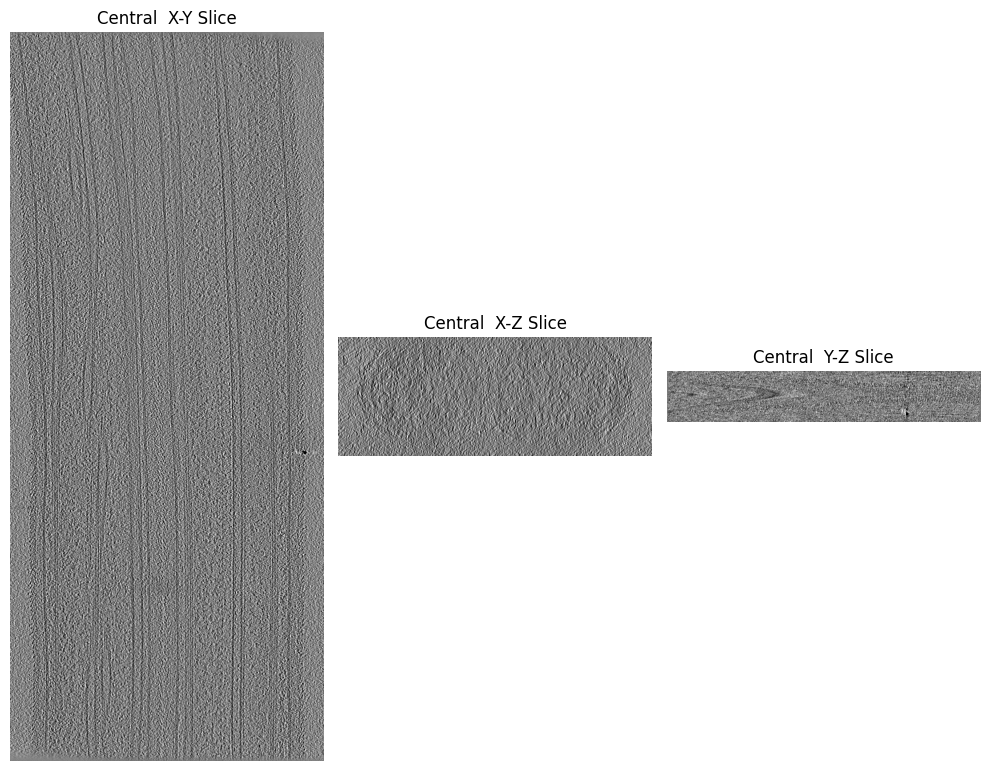

In [3]:
tomo_full = load_mrc_data("./tutorial_data/tomo_all_frames.rec")
plot_tomo_slices(
    tomo_full.clamp(-3 * tomo_full.std(), 3 * tomo_full.std()), figsize=(10, 20)
).show()


In [4]:
import ddw
import os

ddw_path = os.path.dirname(ddw.__file__)
print(ddw_path)

C:\Users\fabio\Coding\DeepDeWedge\ddw


In [5]:
vis_path = os.path.join(ddw_path, "utils", "visualization.py")
print(vis_path)

C:\Users\fabio\Coding\DeepDeWedge\ddw\utils\visualization.py


In [6]:
with open(vis_path, "r") as f:
    txt = f.read()

start = txt.find("def plot_tomo_slices")
print(txt[start:start+2000])

def plot_tomo_slices(tomo, domain="image", figsize=(7, 5)):
    # docstring
    """
    Plot central slices of a 3D tomogram in either image or Fourier domain.
    """
    fig, ax = plt.subplots(1, 3, figsize=figsize)
    # plot in image domain
    half = (torch.tensor(tomo.shape) / 2).floor().int()
    if domain == "image":
        ax[0].imshow(tomo[half[0], :, :], cmap="gray")
        ax[1].imshow(tomo[:, half[1], :], cmap="gray")
        ax[2].imshow(tomo[:, :, half[2]], cmap="gray")
    elif domain == "fourier":
        # plot in Fourier domain
        tomo_ft = fft_3d(tomo).abs()
        ax[0].imshow(tomo_ft[half[0], :, :], cmap="gray")
        ax[1].imshow(tomo_ft[:, half[1], :], cmap="gray")
        ax[2].imshow(tomo_ft[:, :, half[2]].T, cmap="gray")
    # layout
    ax[1].set_title(f"Central {'Fourier' if domain=='fourier' else ''} X-Z Slice")
    ax[2].set_title(f"Central {'Fourier' if domain=='fourier' else ''} Y-Z Slice")
    ax[0].set_title(f"Central {'Fourier' if domain=='

In [7]:
fourier_path = os.path.join(ddw_path, "utils", "fourier.py")
print(fourier_path)

with open(fourier_path, "r") as f:
    txt = f.read()

start = txt.find("def get_3d_fft_freqs_on_grid")
print(txt[start:start+2000])

C:\Users\fabio\Coding\DeepDeWedge\ddw\utils\fourier.py
def get_3d_fft_freqs_on_grid(grid_size, device="cpu"):
    """
    Produces a 3D tensor with shape 'grid_size' whose entries are the spatial frequencies that correspond to the entries of a fourier transform computed with 'fft_3d'.
    """
    z = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[0]), device=device))
    y = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[1]), device=device))
    x = torch.fft.fftshift(torch.fft.fftfreq(int(grid_size[2]), device=device))
    grid = torch.cartesian_prod(z, y, x)
    return grid

